In [1]:
import os
import json
from ast import literal_eval
from datetime import datetime, timedelta

import pandas as pd

import numpy as np
from IPython.display import clear_output

from python_utilities.db_connection import DbConnection


In [2]:
analytics_db = DbConnection('ANALYTICS', 'PROD_RDS')

INFO [2026-07-15 09:46:13] - PYTHON_UTILITIES - secret_utilities.py - get_db_secret_config - Credentials for database were read from secret.ini file


In [3]:
start_date = "2026-06-01"
end_date = "2026-07-01"


egvp_attachments = analytics_db.sql_to_df(f"""
    SELECT la.*, lt.egvp_id
    FROM llm_attachments la
    LEFT JOIN llm_tickets lt
    ON la.ticket_uuid = lt.ticket_uuid
    WHERE la.created_at >= '{start_date}'
    AND la.created_at < '{end_date}'
""")

egvp_attachments = egvp_attachments[~egvp_attachments['attachment_id'].str.contains('-')]

In [4]:
egvp_intents = analytics_db.sql_to_df(f"""
    SELECT *
    FROM egvp_intents
    WHERE created_at >= '{start_date}'
    AND created_at <= '{end_date}'
    AND intents LIKE '%%"channel": "egvp"%%'
    AND attachment_id IN ({', '.join([f"'{att_id}'" for att_id in egvp_attachments.attachment_id.unique()])})
""")


In [24]:
egvp_attachments.shape

(13241, 13)

In [25]:
egvp_intents.shape

(13240, 11)

In [5]:
egvp_intents

,id,ticket_uuid,attachment_id,egvp_id,created_at,intents,ready_for_automation,status,retry,target_type,updated_at
0,33521,ad04fb65-f04a-5557-accf-bc8de58c1f63,66964484,NRW_B2178027206323956923770-e2a0-48e0-8c7d-d39...,2026-06-01 02:07:23,"[{""params"": {""slug"": ""143112083983"", ""debtor_n...",1,sent,0,egvp,2026-06-01 02:07:23
1,33522,47d2716d-6c50-5624-b623-b07152806aaf,66977396,NRW_B21780283786682100b440f-778d-4ad3-b512-0e1...,2026-06-01 05:50:29,"[{""params"": {}, ""channel"": ""egvp"", ""attachment...",0,sent,0,egvp,2026-06-01 05:50:29
2,33523,416daf34-5232-5a41-83f1-85fd43020475,66979093,NRW_B2178028965795706d896b6-36b7-4063-b9b5-2ae...,2026-06-01 06:28:57,"[{""params"": {}, ""channel"": ""egvp"", ""attachment...",0,sent,0,egvp,2026-06-01 06:28:57
3,33524,818e250a-7909-50ea-83dc-fc5c761ccf7b,66979629,NRW_B217802884687215267e12f-16e9-4aba-8298-38d...,2026-06-01 06:28:59,"[{""params"": {}, ""channel"": ""egvp"", ""attachment...",0,sent,0,egvp,2026-06-01 06:28:59
4,33525,818e250a-7909-50ea-83dc-fc5c761ccf7b,66979630,NRW_B217802884687215267e12f-16e9-4aba-8298-38d...,2026-06-01 06:28:59,"[{""params"": {}, ""channel"": ""egvp"", ""attachment...",0,sent,0,egvp,2026-06-01 06:28:59
...,...,...,...,...,...,...,...,...,...,...,...
13235,47015,5ebecf6c-93ce-5719-ba82-3a464cfd22f9,70460250,NRW_B217828517383486da9cae3-619e-4438-8516-42b...,2026-06-30 22:34:34,"[{""params"": {""slug"": ""184518894417"", ""end_page...",0,sent,0,egvp,2026-06-30 22:34:34
13236,47016,a669847f-55e1-5105-8acd-0382d41fb662,70460235,NRW_B21782849834342ed63fff5-e684-451b-aa38-847...,2026-06-30 22:34:38,"[{""params"": {""slug"": ""183702796198"", ""end_page...",0,sent,0,egvp,2026-06-30 22:34:38
13237,47017,c4ba5e2f-1535-5561-a811-3e2161d88da1,70460241,NRW_B21782851235444c9c17233-8b4c-4286-8b6e-be9...,2026-06-30 22:34:40,"[{""params"": {""slug"": ""192307097027""}, ""channel...",1,sent,0,egvp,2026-06-30 22:34:40
13238,47018,ff4b7bed-d325-50ef-a5dd-83e8012b2924,70460244,NRW_B2178284984357849555590-f86b-41c8-984b-4be...,2026-06-30 22:34:41,"[{""params"": {""slug"": ""184266800251"", ""debtor_n...",1,sent,0,egvp,2026-06-30 22:34:41


In [21]:
egvp_intents.created_at.max(), egvp_intents.created_at.min()

(Timestamp('2026-06-30 22:34:45'), Timestamp('2026-06-01 02:07:23'))

In [26]:
total_found_intents = len(egvp_intents)
total_attachments_given_dates = egvp_attachments['attachment_id'].nunique()
total_processed_attachments = egvp_attachments[egvp_attachments['status'] == 'processed']['attachment_id'].nunique()
total_rejected_attachments = egvp_attachments[egvp_attachments['status'] == 'rejected_too_long']['attachment_id'].nunique()
print("Total found intents: {}, total attachments given dates: {}, total processed attachments: {}, total rejected attachments: {}".format(
    total_found_intents,
    total_attachments_given_dates,
    total_processed_attachments,
    total_rejected_attachments
))

Total found intents: 13240, total attachments given dates: 13241, total processed attachments: 12413, total rejected attachments: 826


In [27]:
egvp_intents['attachment_id'] = egvp_intents['attachment_id'].astype(str)

In [28]:
intent_cant_found_attachment_ids = set(egvp_attachments['attachment_id'].unique()) - set(egvp_intents['attachment_id'].unique())

In [29]:
len(intent_cant_found_attachment_ids)

1

In [30]:
print("Total intents:", len(egvp_intents))
print("Unique attachments in intents:", egvp_intents['attachment_id'].nunique())
print("Intents can't found for {} attachments.".format(len(intent_cant_found_attachment_ids)))

Total intents: 13240
Unique attachments in intents: 13240
Intents can't found for 1 attachments.


In [31]:
detection_from_intents_db = egvp_attachments.merge(
    egvp_intents[['attachment_id', 'intents','ready_for_automation']],
    on='attachment_id',
    how='inner'
)

In [32]:
def find_how_detected(row):
    intent = row['intents']
    if intent:
        try:
            intent = intent.lower()
        except:
            return "none"
        if "ladung_va" in intent:
            return "ladung_va"
        elif "pfub_erlass" in intent:
            return "pfub_erlass"
        elif "vermogen" in intent:
            return "va"
        elif "dritt" in intent:
            return "dritt"
        elif '"aftercourt_type": "invoice"' in intent:
            return "invoice"
        else:
            return "none"
    else:
        return "none"
        

detection_from_intents_db['how_detected'] = detection_from_intents_db.apply(lambda row: find_how_detected(row) , axis=1)

In [36]:
detection_from_intents_db['how_detected'].value_counts()

how_detected
none           6139
pfub_erlass    1884
invoice        1681
dritt          1676
ladung_va      1661
va              199
Name: count, dtype: int64

Total: 13240
              count  percentage
how_detected                   
none           6139       46.37
pfub_erlass    1884       14.23
invoice        1681       12.70
dritt          1676       12.66
ladung_va      1661       12.55
va              199        1.50


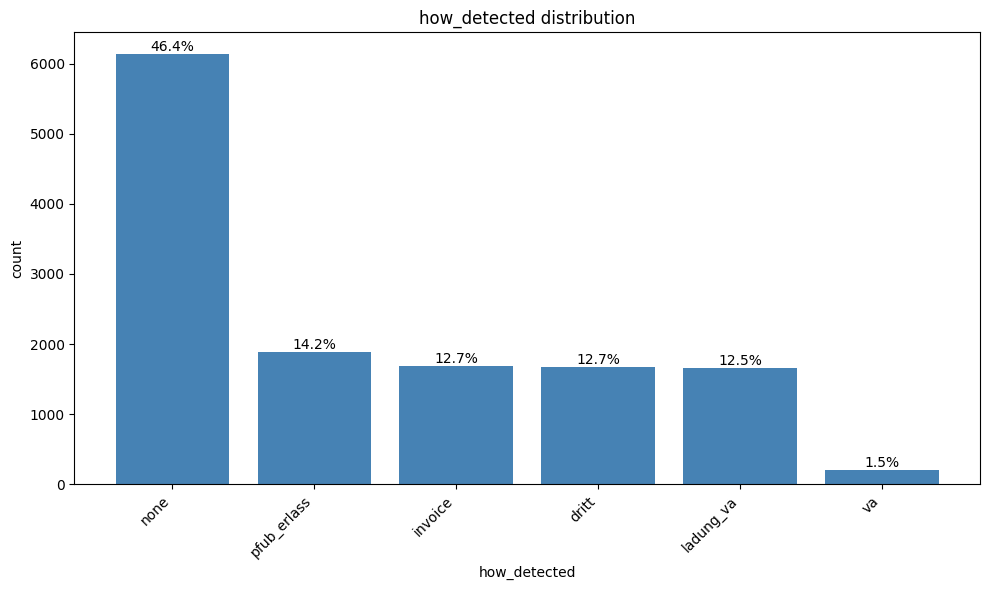

In [41]:
import matplotlib.pyplot as plt

counts = detection_from_intents_db['how_detected'].value_counts()
percentages = detection_from_intents_db['how_detected'].value_counts(normalize=True) * 100

stats = pd.DataFrame({
    'count': counts,
    'percentage': percentages.round(2)
})
print("Total:", counts.sum())
print(stats)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(counts.index, counts.values, color='steelblue')
ax.set_title('how_detected distribution')
ax.set_xlabel('how_detected')
ax.set_ylabel('count')
plt.xticks(rotation=45, ha='right')

for bar, pct in zip(bars, percentages.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


In [42]:
total_rows = len(detection_from_intents_db)
detected = (detection_from_intents_db['how_detected'] != 'none').sum()
not_detected = total_rows - detected
detection_percentage = detected / total_rows * 100

print(f"Total: {total_rows}")
print(f"Detected: {detected} ({detection_percentage:.2f}%)")
print(f"Not detected: {not_detected} ({100 - detection_percentage:.2f}%)")


Total: 13240
Detected: 7101 (53.63%)
Not detected: 6139 (46.37%)
